In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf 

In [2]:
# -------- FETCH LIVE MARKET DATA ---------
ticker = 'MSFT' # Microsoft
start_date = '2024-01-01'
end_date = '2025-12-31'
print(f"Fetching historical data for {ticker}")
df = yf.download(ticker, start=start_date, end=end_date)
# Clean multi-level index if present in newer finance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

Fetching historical data for MSFT


[*********************100%***********************]  1 of 1 completed


In [4]:
# ------- DEFINING THE TRADING STRATEGY --------
print("Calculating moving averages and trading signals ....")
# Fast moving average (20 days) and Slow moving average (50 days)
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()
# Drop rows with NaN values from the rolling window buffer 
df = df.dropna().copy()
# Generate Signals:
# Buy (1) when SMA20 is higher than SMA50 , otherwise Hold/Sell
df['Signal'] = np.where(df['SMA20']>df['SMA50'], 1, 0)
# Calculate daily positions changes (1=Buyer trigger, -1=Seller trigger)
df['Position_Change'] = df['Signal'].diff()

Calculating moving averages and trading signals ....


In [5]:
# -------- BACKTEST RETURNS -------
print("Simulating strategy returns...")
# Calculate buy-and-hold daily market returns
df['Market_Returns'] = df['Close'].pct_change()
# Our strategy returns: since we get the signal at the close of day T, 
# we capture day T+1's return. Shift the signal by 1 day.
df['Strategy_Returns'] = df['Market_Returns'] * df['Signal'].shift(1)
# Calculate cumulative performance
df['Cumulative_Market'] = (1 + df['Market_Returns'].fillna(0)).cumprod() - 1
df['Cumulative_Strategy'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod() - 1
final_market_perf = df['Cumulative_Market'].iloc[-1] * 100
final_strategy_perf = df['Cumulative_Strategy'].iloc[-1] * 100
print(f"\n================ PERFORMANCE METRICS ================")
print(f"Buy & Hold Market Return : {final_market_perf:.2f}%")
print(f"Algorithmic Strategy Return: {final_strategy_perf:.2f}%")

Simulating strategy returns...

================ PERFORMANCE METRICS ================
Buy & Hold Market Return : 14.50%
Algorithmic Strategy Return: -2.24%


Plotting strategy execution...


AttributeError: Line2D.set() got an unexpected keyword argument 'separators'

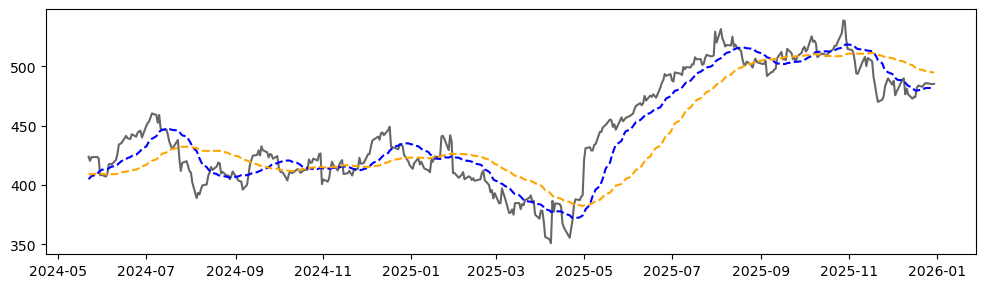

In [6]:
# -------- VISUALIZE THE BACKTEST ---------
print("Plotting strategy execution...")
plt.figure(figsize=(12, 7))
# Subplot 1: Price and SMA Crossovers
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], label='Close Price', color='black', alpha=0.6)
plt.plot(df.index, df['SMA20'], label='20-day SMA (Fast)', color='blue', linestyle='--')
plt.plot(df.index, df['SMA50'], label='50-day SMA (Slow)', color='orange', linestyle='--')
# Plot Buy Signals
plt.plot(df[df['Position_Change'] == 1].index, 
         df['SMA20'][df['Position_Change'] == 1], 
         '^', separators=None, markersize=10, color='g', label='BUY Signal', lw=0)
# Plot Sell Signals
plt.plot(df[df['Position_Change'] == -1].index, 
         df['SMA20'][df['Position_Change'] == -1], 
         'v', separators=None, markersize=10, color='r', label='SELL Signal', lw=0)
plt.title(f'{ticker} Algorithmic Backtest Sandpit', fontsize=14, fontweight='bold')
plt.ylabel('Stock Price ($)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
# Subplot 2: Cumulative Returns Comparison
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Cumulative_Market'] * 100, label='Buy & Hold Market', color='gray', linestyle=':')
plt.plot(df.index, df['Cumulative_Strategy'] * 100, label='Algo Strategy', color='green', lw=2)
plt.ylabel('Cumulative Growth (%)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("algo_backtest_results.png")
plt.show()